# GANisme — 10. Un second genre : les paysages

**La question.** Tout le travail des notebooks 04 à 09 a porté sur les portraits. Ce qu'on y a appris —
l'équilibre entre les deux réseaux, les hyperparamètres trouvés par Optuna, le passage en haute résolution —
est-il **propre aux portraits**, ou se transpose-t-il à un autre genre ?

**La démarche.** On ne refait pas tout le parcours (trois modèles, puis une étude Optuna). On procède en trois
entraînements, du plus simple au plus ambitieux :

| # | Modèle | Résolution | Ce qu'il teste |
|---|---|---|---|
| a | DCGAN de base (hyperparamètres de l'article) | 64×48 | le point de départ, équivalent du modèle n°1 des portraits |
| b | Hyperparamètres d'Optuna trouvés **sur les portraits** (réglage n°26), repris tels quels | 64×48 | se transposent-ils à un autre genre ? |
| c | Le même réglage, une couche de plus, largeur 64 | 128×96 | la montée en résolution fonctionne-t-elle aussi ici ? |

**Les données** (notebook 03) : 2 714 paysages d'entraînement, 302 de test, au format 4:3 horizontal. Le générateur
part d'une grille 3×4 (hauteur × largeur) au lieu de 5×4.

| | |
|---|---|
| Code | `src/run_landscape.py` (file d'entraînements reprenable) |
| Commande | `python src/run_landscape.py` |

**Rappel de lecture.** Chaque genre et chaque résolution a sa propre échelle de référence : les scores des paysages
ne se comparent pas à ceux des portraits, ni ceux en 128×96 à ceux en 64×48.

**Limite annoncée** : un seul entraînement par modèle.

In [1]:
import json
import shutil
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
from PIL import Image
from matplotlib_inline.backend_inline import set_matplotlib_formats

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import dataset as ds          # noqa: E402
import generate as gn         # noqa: E402
import metrics as mt          # noqa: E402
import train as tr            # noqa: E402

FIG_DIR = ROOT / "reports" / "figures"
RUNS = ROOT / "runs"
GENRE, BIG, SMALL = "landscape", (128, 96), (64, 48)
set_matplotlib_formats("jpeg", pil_kwargs={"quality": 88})

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MAIN, OTHER = CAT[0], "#c3c2b7"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": OTHER,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"paysage_{name}.png")


MODELS = {"landscape_64_dcgan_s42": ("a · DCGAN de base, 64×48", MUTED),
          "landscape_64_best_s42": ("b · réglage Optuna, 64×48", CAT[0]),
          "landscape_128_w64_s42": ("c · réglage Optuna, 128×96", CAT[1])}
runs = {n: {"cfg": json.loads((RUNS / n / "config.json").read_text(encoding="utf-8")),
            "eval": pd.read_csv(RUNS / n / "eval.csv"), "hist": pd.read_csv(RUNS / n / "history.csv")} for n in MODELS}
baselines = pd.read_csv(ROOT / "reports" / "metrics" / "baselines.csv")
bl = {r: baselines[(baselines["genre"] == GENRE) & (baselines["résolution"] == r)].set_index("baseline") for r in ("64×48", "128×96")}
cols = ["FID", "FID_ntest", "KID_x1000", "precision", "recall", "density", "coverage", "mem_ratio", "copies"]
for n, r in runs.items():
    print(f"{MODELS[n][0]} : {r['cfg']['epochs']} époques, {r['hist']['seconds'].mean():.1f} s par époque, "
          f"{r['hist']['seconds'].sum() / 60:.0f} min de calcul hors évaluations")

meta = pd.read_csv(ds.DATASETS / GENRE / "metadata.csv")
print(f"\nJeu de données : {meta['SPLIT'].value_counts().to_dict()}")
print("Siècles :", meta["CENTURY"].value_counts().sort_index().to_dict())
print("Écoles :", meta["SCHOOL"].value_counts().head(5).to_dict())

a · DCGAN de base, 64×48 : 500 époques, 0.9 s par époque, 7 min de calcul hors évaluations
b · réglage Optuna, 64×48 : 600 époques, 1.6 s par époque, 16 min de calcul hors évaluations
c · réglage Optuna, 128×96 : 600 époques, 7.3 s par époque, 73 min de calcul hors évaluations

Jeu de données : {'train': 2714, 'test': 302}
Siècles : {14: 1, 15: 3, 16: 113, 17: 1104, 18: 585, 19: 1210}
Écoles : {'Dutch': 849, 'French': 760, 'Italian': 396, 'Flemish': 363, 'English': 156}


## 1. En 64×48 : les réglages des portraits se transposent-ils ?

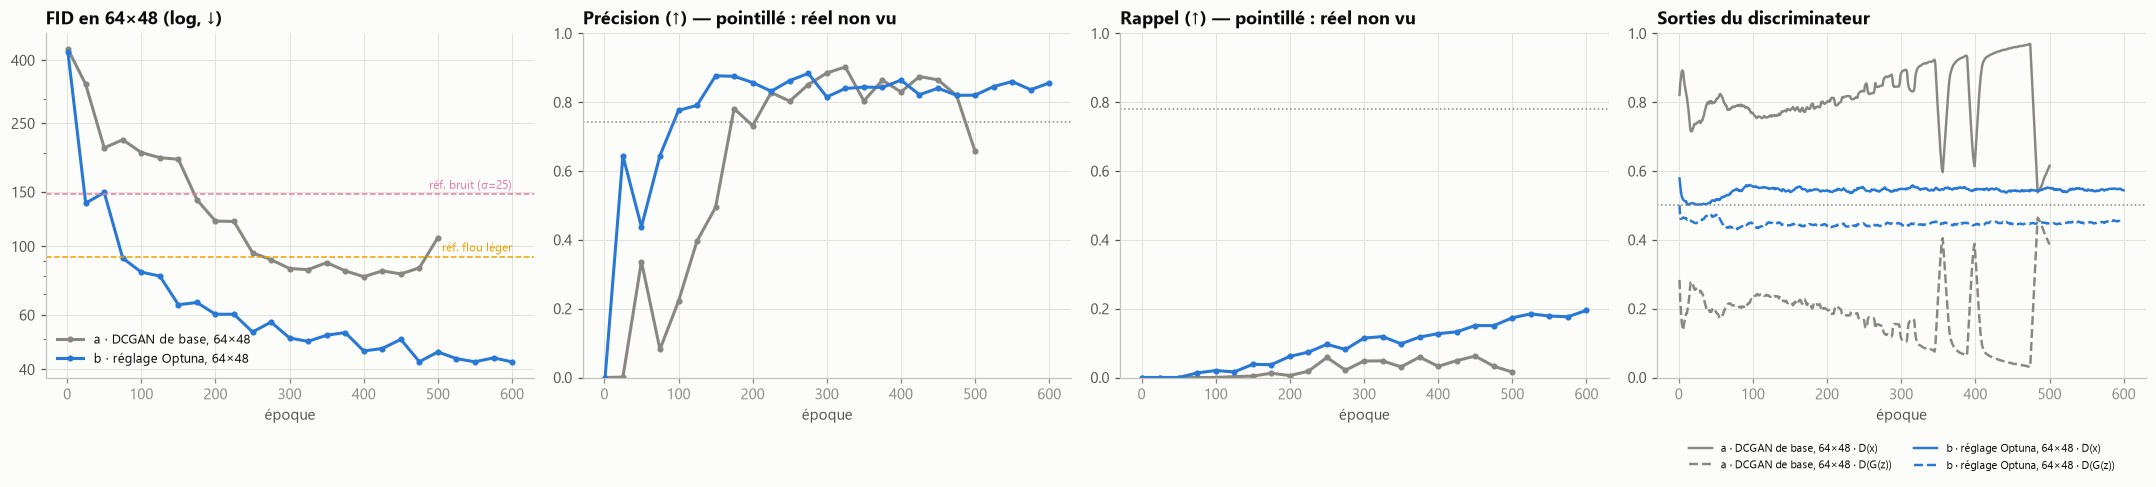

,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
"a · DCGAN de base, 64×48 (meilleur : époque 400)",79.819,112.309,67.256,0.830,0.032,0.915,0.398,0.943,0.001
"b · réglage Optuna, 64×48 (meilleur : époque 600)",42.324,77.455,26.553,0.856,0.195,1.198,0.703,0.956,0.001
"a · DCGAN de base, dernière époque",106.798,137.278,101.590,0.657,0.016,0.417,0.196,0.985,0.000
réf. · Réel non vu (test),58.485,58.485,-0.079,0.742,0.781,0.966,0.398,1.000,0.013
réf. · Flou léger,92.654,140.864,81.280,0.421,0.465,0.160,0.235,1.202,0.000
réf. · Bruit (σ=25),147.553,193.876,141.415,0.368,0.216,0.130,0.073,1.296,0.000
réf. · Mode collapse (20 images),185.322,183.440,18.306,1.000,0.006,0.871,0.034,0.001,1.000


In [2]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
for n in ["landscape_64_dcgan_s42", "landscape_64_best_s42"]:
    e, h, (lbl, col) = runs[n]["eval"], runs[n]["hist"], MODELS[n]
    axes[0].plot(e["epoch"], e["FID"], color=col, marker="o", ms=3, label=lbl)
    axes[1].plot(e["epoch"], e["precision"], color=col, marker="o", ms=3)
    axes[2].plot(e["epoch"], e["recall"], color=col, marker="o", ms=3)
    axes[3].plot(h["epoch"], h["d_real"].rolling(10, min_periods=1).mean(), color=col, lw=1.6, label=f"{lbl} · D(x)")
    axes[3].plot(h["epoch"], h["d_fake"].rolling(10, min_periods=1).mean(), color=col, lw=1.6, ls="--", label=f"{lbl} · D(G(z))")
for lbl, c in [("Flou léger", CAT[3]), ("Bruit (σ=25)", CAT[4])]:
    axes[0].axhline(bl["64×48"].loc[lbl, "FID"], color=c, ls="--", lw=1)
    axes[0].text(600, bl["64×48"].loc[lbl, "FID"] * 1.04, f"réf. {lbl.lower()}", ha="right", fontsize=8, color=c)
axes[0].set_yscale("log"); axes[0].set_yticks([40, 60, 100, 150, 250, 400])
axes[0].yaxis.set_major_formatter(mtick.ScalarFormatter()); axes[0].yaxis.set_minor_formatter(mtick.NullFormatter())
axes[0].set_title("FID en 64×48 (log, ↓)"); axes[0].legend(loc="lower left", fontsize=8.5)
for ax, key, title in [(axes[1], "precision", "Précision (↑)"), (axes[2], "recall", "Rappel (↑)")]:
    ax.axhline(bl["64×48"].loc["Réel non vu (test)", key], color=MUTED, ls=":", lw=1)
    ax.set_ylim(0, 1); ax.set_title(title + " — pointillé : réel non vu")
axes[3].axhline(0.5, color=MUTED, ls=":", lw=1); axes[3].set_ylim(0, 1)
axes[3].set_title("Sorties du discriminateur"); axes[3].legend(fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
for ax in axes:
    ax.set_xlabel("époque")
plt.tight_layout()
save(fig, "01_curves_64")
plt.show()

t64 = pd.DataFrame({MODELS[n][0] + f" (meilleur : époque {int(runs[n]['eval'].loc[runs[n]['eval']['FID'].idxmin(), 'epoch'])})":
                    runs[n]["eval"].loc[runs[n]["eval"]["FID"].idxmin(), cols] for n in ["landscape_64_dcgan_s42", "landscape_64_best_s42"]}).T
t64.loc["a · DCGAN de base, dernière époque"] = runs["landscape_64_dcgan_s42"]["eval"].iloc[-1][cols]
refs = bl["64×48"].loc[["Réel non vu (test)", "Flou léger", "Bruit (σ=25)", "Mode collapse (20 images)"], cols]
refs.index = "réf. · " + refs.index
pd.concat([t64, refs]).astype(float).round(3)

**Observations**

- **Le DCGAN de base part de plus haut que sur les portraits** : FID de 79,8 à son meilleur point (époque 400), déjà
  sous le niveau « flou léger » des paysages (93). Le genre est plus tolérant : pas de visage à réussir.
- **Mais il a les deux défauts du modèle n°1 des portraits.** Son discriminateur domine (il donne en moyenne 0,84 aux
  vraies images et 0,16 aux fausses, avec des crises), et l'entraînement se dégrade à la fin : le FID remonte à 106,8
  à la dernière époque. Sa diversité est très faible : rappel de 0,03.
- **Les hyperparamètres trouvés sur les portraits se transposent sans aucun réglage.** Le FID tombe à **42,3**, soit
  presque deux fois moins. Le discriminateur reste à l'équilibre du début à la fin (0,55 / 0,45), exactement comme
  sur les portraits.
- **Le gain vient surtout de la diversité** : rappel de 0,03 à 0,20, couverture de 0,40 à 0,70. La précision, déjà
  haute, bouge peu (0,83 → 0,86).
- **L'apprentissage est plus rapide dès le départ** (FID de 83 à l'époque 100, contre 201) et **n'est pas terminé à
  l'époque 600** : le meilleur score est celui de la dernière époque.
- **Mémorisation** : `mem_ratio` de 0,94 à 0,96, un peu sous 1, avec 0,1 % de copies. Les images ne sont pas recopiées,
  mais elles sont légèrement plus proches du jeu d'entraînement que ne le sont de vraies peintures inconnues.
  Interprétation : ces modèles produisent des paysages « typiques », situés dans les zones denses de la distribution
  (densité supérieure à 1), donc toujours assez proches d'une œuvre existante. La section 5 le vérifie.

## 2. En 128×96 : la montée en résolution

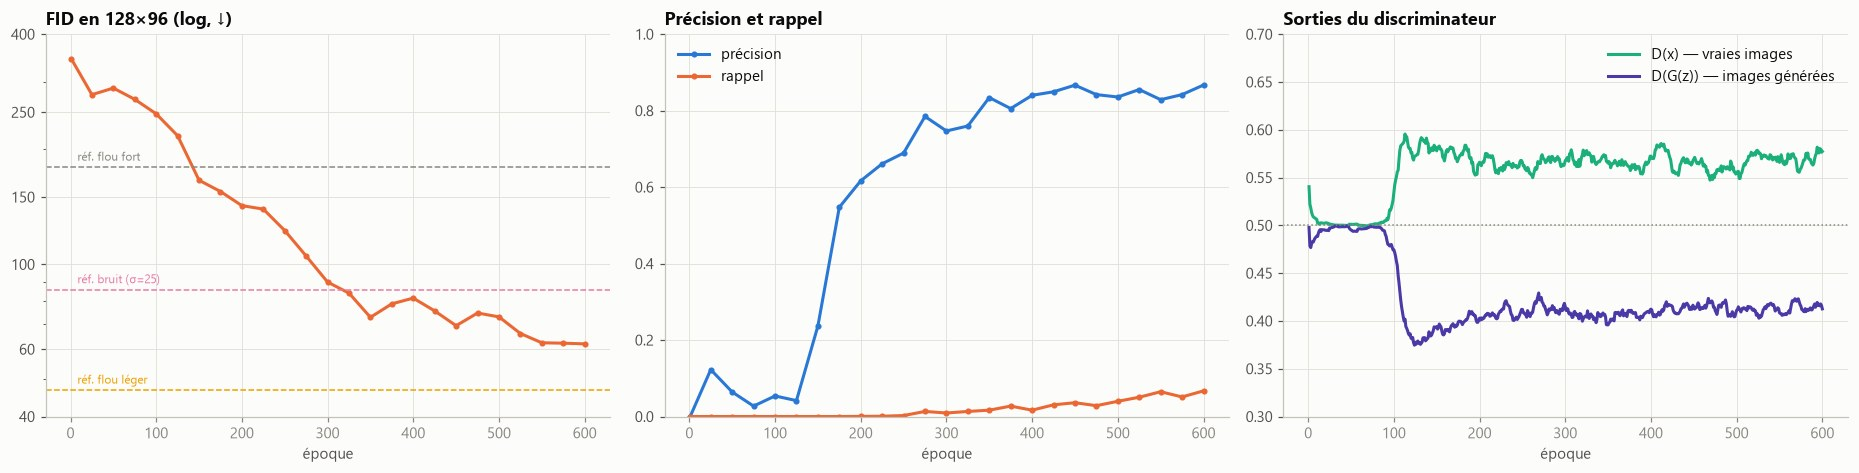

Meilleur FID : 61.9 à l'époque 600 ; époque 600 : 61.9 ; étendue sur les époques 450 à 600 : 61.9 à 74.6


,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
"c · réglage Optuna, 128×96 (époque 600)",61.949,92.991,41.220,0.867,0.067,1.180,0.519,1.002,0.000
réf. · Réel non vu (test),55.490,55.490,-0.153,0.778,0.791,0.887,0.377,1.000,0.013
réf. · Flou léger,46.874,91.343,33.723,0.716,0.860,0.240,0.697,1.023,0.015
réf. · Bruit (σ=25),85.803,131.878,67.902,0.242,0.392,0.074,0.189,1.242,0.000
réf. · Flou fort,179.484,223.749,156.338,0.054,0.016,0.012,0.012,1.514,0.000
réf. · Mode collapse (20 images),185.599,187.701,21.838,1.000,0.006,1.119,0.042,0.001,1.000


In [3]:
e, h = runs["landscape_128_w64_s42"]["eval"], runs["landscape_128_w64_s42"]["hist"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
axes[0].plot(e["epoch"], e["FID"], color=CAT[1], marker="o", ms=3)
for lbl, c in [("Flou léger", CAT[3]), ("Bruit (σ=25)", CAT[4]), ("Flou fort", MUTED)]:
    axes[0].axhline(bl["128×96"].loc[lbl, "FID"], color=c, ls="--", lw=1)
    axes[0].text(8, bl["128×96"].loc[lbl, "FID"] * 1.04, f"réf. {lbl.lower()}", ha="left", fontsize=8, color=c)
axes[0].set_yscale("log"); axes[0].set_yticks([40, 60, 100, 150, 250, 400])
axes[0].yaxis.set_major_formatter(mtick.ScalarFormatter()); axes[0].yaxis.set_minor_formatter(mtick.NullFormatter())
axes[0].set_title("FID en 128×96 (log, ↓)")
axes[1].plot(e["epoch"], e["precision"], color=CAT[0], marker="o", ms=3, label="précision")
axes[1].plot(e["epoch"], e["recall"], color=CAT[1], marker="o", ms=3, label="rappel")
axes[1].set_ylim(0, 1); axes[1].set_title("Précision et rappel"); axes[1].legend()
axes[2].plot(h["epoch"], h["d_real"].rolling(10, min_periods=1).mean(), color=CAT[2], label="D(x) — vraies images")
axes[2].plot(h["epoch"], h["d_fake"].rolling(10, min_periods=1).mean(), color=CAT[6], label="D(G(z)) — images générées")
axes[2].axhline(0.5, color=MUTED, ls=":", lw=1); axes[2].set_ylim(0.3, 0.7); axes[2].set_title("Sorties du discriminateur"); axes[2].legend()
for ax in axes:
    ax.set_xlabel("époque")
plt.tight_layout()
save(fig, "02_curves_128")
plt.show()

b = e.loc[e["FID"].idxmin()]
late = e[e["epoch"] >= 450]["FID"]
print(f"Meilleur FID : {b['FID']:.1f} à l'époque {int(b['epoch'])} ; époque 600 : {e['FID'].iloc[-1]:.1f} ; "
      f"étendue sur les époques 450 à 600 : {late.min():.1f} à {late.max():.1f}")
t128 = pd.DataFrame({MODELS["landscape_128_w64_s42"][0] + f" (époque {int(b['epoch'])})": b[cols]}).T
refs = bl["128×96"].loc[["Réel non vu (test)", "Flou léger", "Bruit (σ=25)", "Flou fort", "Mode collapse (20 images)"], cols]
refs.index = "réf. · " + refs.index
pd.concat([t128, refs]).astype(float).round(3)

**Observations**

- **Un démarrage très lent.** Pendant les 90 premières époques, le discriminateur est resté exactement au hasard
  (0,50 pour les vraies images comme pour les fausses) : sans signal, le générateur ne progresse pas. Le déblocage se
  produit vers l'époque 100. Le modèle n'a donc disposé que d'environ 500 époques utiles. Le même phénomène avait été
  observé sur les portraits en 128×160, en plus court (une cinquantaine d'époques).
- **Une fois lancé, l'entraînement est stable** : discriminateur proche de l'équilibre (0,57 / 0,41), aucune crise.
- **Le FID final est de 61,9**, entre « flou léger » (47) et « bruit » (86) sur l'échelle de référence en 128×96.
  Le meilleur score est celui de la dernière époque : **le modèle progressait encore**.
- **Précision très haute (0,87, au-dessus du réel à 0,78), rappel très bas (0,07).** Les images ressemblent à des
  paysages, mais le générateur couvre mal la variété des détails fins — même constat que pour les portraits.
- **Aucune mémorisation** : `mem_ratio` de 1,00, 0 % de copies.
- Note : le PC s'est mis en veille 70 minutes pendant cet entraînement. Le calcul a repris de lui-même au réveil ;
  les durées affichées ici sont des temps de calcul effectifs.

## 3. Comparaison équitable : les trois modèles évalués en 64×48

Comme pour les portraits (notebook 09), les images du modèle 128×96 sont réduites en 64×48 avec le même filtre que
celui du jeu de données, puis évaluées contre la même référence que les deux autres.

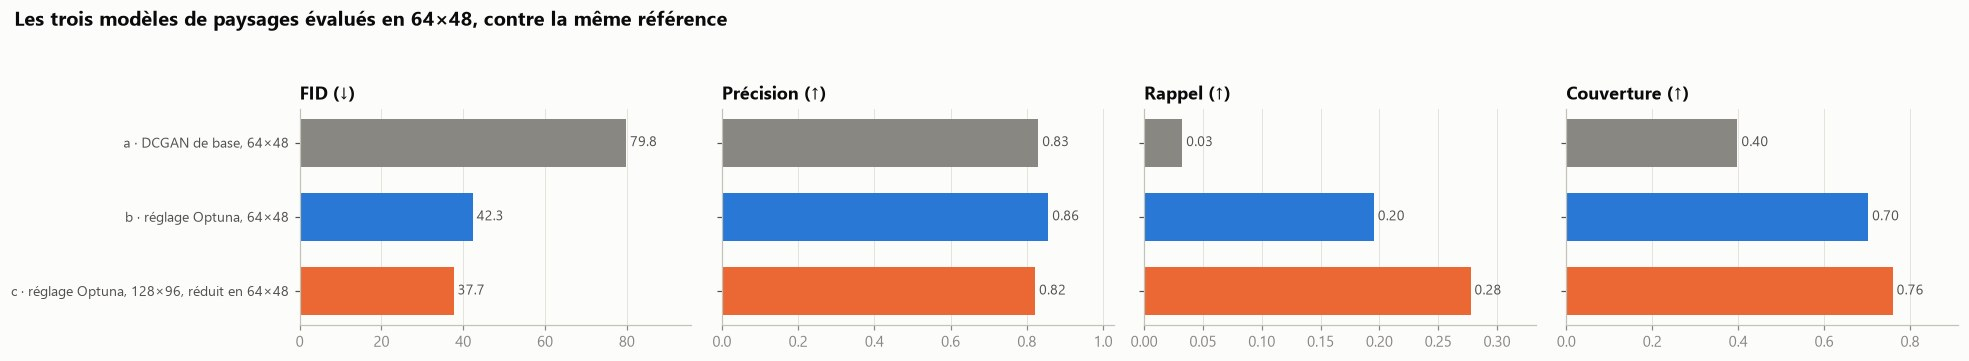

,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
"a · DCGAN de base, 64×48",79.819,112.309,67.256,0.830,0.032,0.915,0.398,0.943,0.001
"b · réglage Optuna, 64×48",42.324,77.455,26.553,0.856,0.195,1.198,0.703,0.956,0.001
"c · réglage Optuna, 128×96, réduit en 64×48",37.679,76.700,20.551,0.822,0.277,1.112,0.760,1.000,0.001
réf. · Réel non vu (test),58.485,58.485,-0.079,0.742,0.781,0.966,0.398,1.000,0.013
réf. · Flou léger,92.654,140.864,81.280,0.421,0.465,0.160,0.235,1.202,0.000


In [4]:
ref64 = mt.Reference.load_or_compute(GENRE, SMALL, ds.DATASETS / GENRE)
GEN, rows = {}, {}
for n in MODELS:
    GEN[n], info = gn.load_generator(n, "best")
    if tuple(info["size"]) == SMALL:
        rows[MODELS[n][0]] = pd.Series(info["scores"])[cols]
    else:
        z = tr.evaluation_latents(len(ref64.train), GEN[n].nz, next(GEN[n].parameters()).device, seed=42)
        big = tr.generate(GEN[n], z, batch_size=128).permute(0, 2, 3, 1).cpu().numpy()
        small = np.stack([np.asarray(Image.fromarray(x).resize(SMALL, Image.LANCZOS)) for x in big])
        f, lg = mt.extract_features(small)
        rows[MODELS[n][0] + ", réduit en 64×48"] = pd.Series(mt.evaluate(f, lg, ref64))[cols]
refs = bl["64×48"].loc[["Réel non vu (test)", "Flou léger"], cols]; refs.index = "réf. · " + refs.index
fair = pd.concat([pd.DataFrame(rows).T, refs]).astype(float)
fair.to_csv(ROOT / "reports" / "metrics" / "summary_landscape.csv")

names = list(rows)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.3))
for ax, key, title in zip(axes, ["FID", "precision", "recall", "coverage"], ["FID (↓)", "Précision (↑)", "Rappel (↑)", "Couverture (↑)"]):
    vals = fair.loc[names, key]
    ax.barh(range(len(names)), vals, color=[MUTED, CAT[0], CAT[1]], height=0.65)
    for i, v in enumerate(vals):
        ax.text(v, i, f" {v:.1f}" if key == "FID" else f" {v:.2f}", va="center", fontsize=9, color=INK2)
    ax.set_yticks(range(len(names)), names if ax is axes[0] else [""] * len(names), fontsize=9); ax.invert_yaxis()
    ax.set_xlim(0, vals.max() * 1.2); ax.set_title(title); ax.grid(axis="y", visible=False)
fig.suptitle("Les trois modèles de paysages évalués en 64×48, contre la même référence", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.92))
save(fig, "03_fair_comparison")
plt.show()
fair.round(3)

**Observations**

- **Du DCGAN de base au modèle 128×96, le FID est divisé par 2,1** (de 79,8 à 37,7), à résolution égale.
- **Le passage en 128×96 apporte un gain plus modeste que pour les portraits** : 4,6 points de FID (42,3 → 37,7),
  contre 13 points. Deux explications possibles, non départagées : un paysage n'a pas de visage, donc moins à gagner
  en résolution ; et ce modèle a perdu une centaine d'époques au démarrage et n'avait pas convergé.
- **Le gain porte encore sur la diversité** : rappel de 0,20 à 0,28, couverture de 0,70 à 0,76. La précision recule
  légèrement (0,86 → 0,82).
- Avec un seul entraînement par modèle, l'écart entre b et c reste à confirmer. L'écart entre a et b, lui, est sans
  ambiguïté.

## 4. Les images

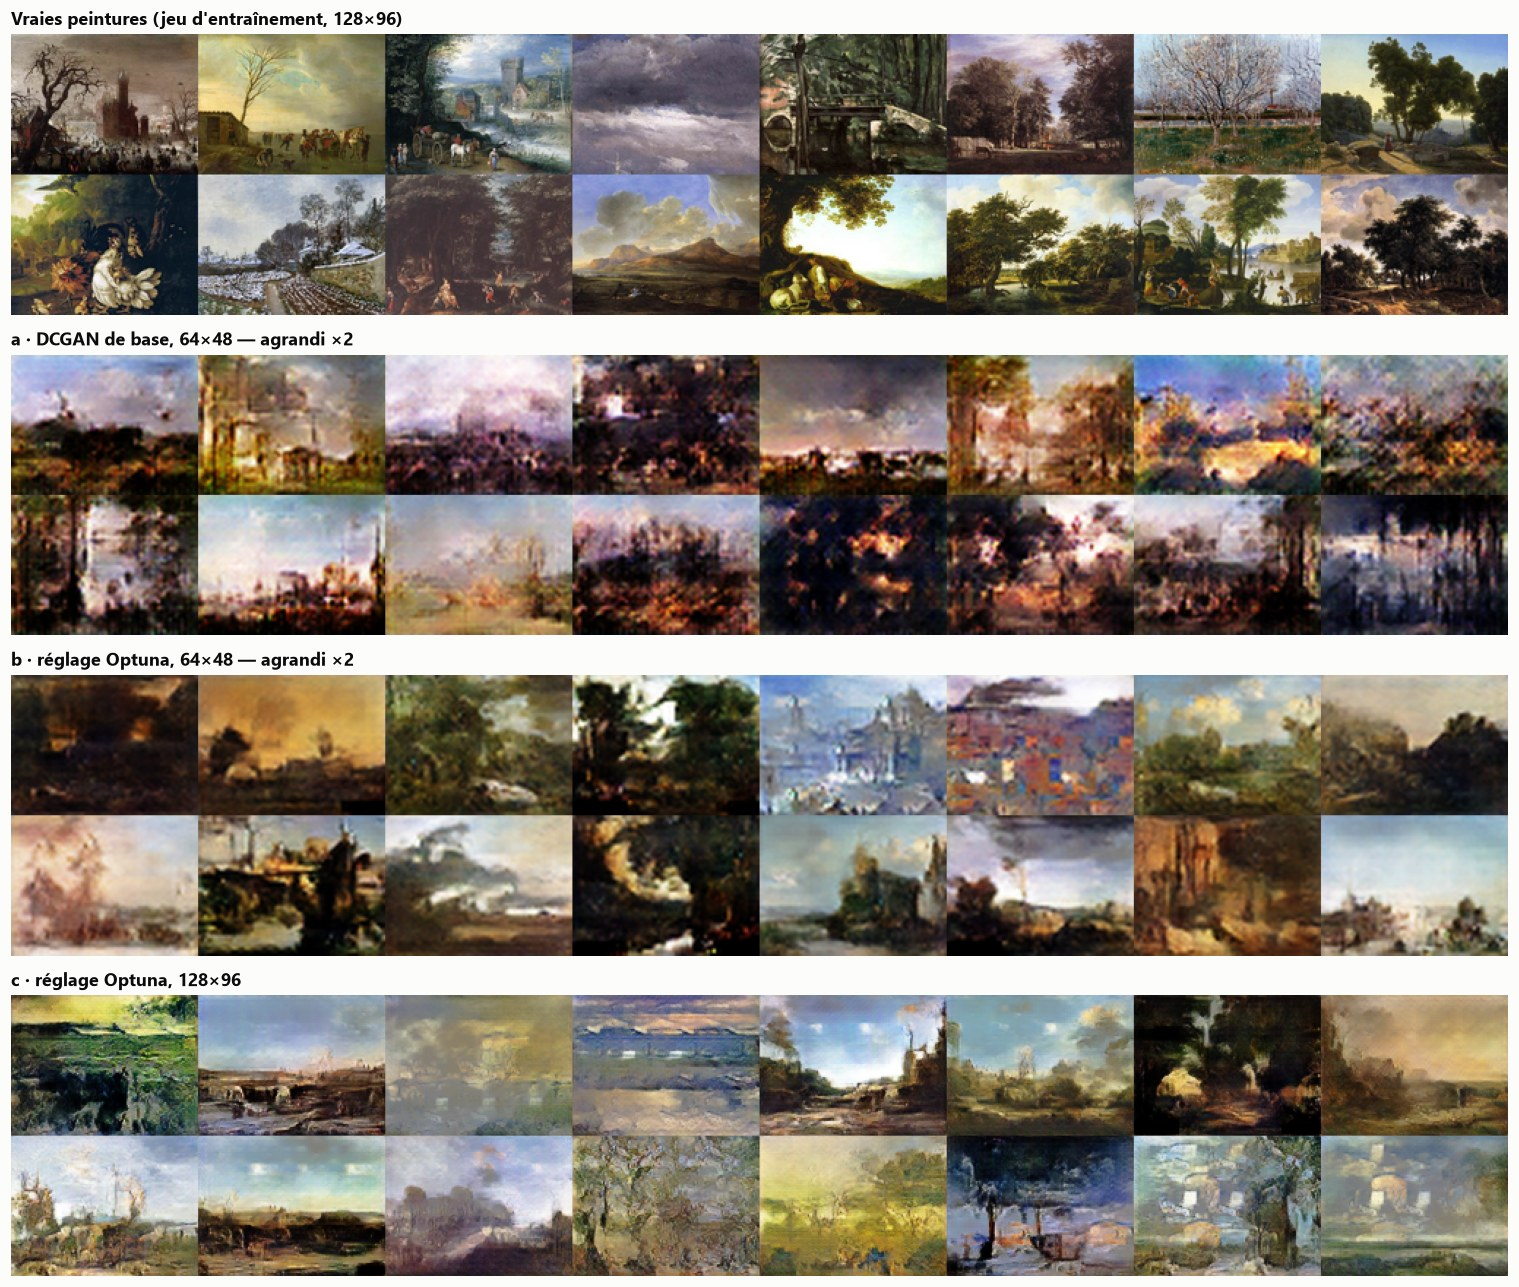

In [5]:
real = ds.load_split(GENRE, "train", BIG)
real = real[np.random.default_rng(123).choice(len(real), 16, replace=False)]
mosaic = lambda imgs, ncol=8: np.concatenate([np.concatenate(list(imgs[i:i + ncol]), axis=1) for i in range(0, len(imgs), ncol)])
up = lambda imgs: np.stack([np.asarray(Image.fromarray(x).resize(BIG, Image.LANCZOS)) for x in imgs])
panels = [("Vraies peintures (jeu d'entraînement, 128×96)", real),
          (MODELS["landscape_64_dcgan_s42"][0] + " — agrandi ×2", up(gn.sample(GEN["landscape_64_dcgan_s42"], 16, seed=123))),
          (MODELS["landscape_64_best_s42"][0] + " — agrandi ×2", up(gn.sample(GEN["landscape_64_best_s42"], 16, seed=123))),
          (MODELS["landscape_128_w64_s42"][0], gn.sample(GEN["landscape_128_w64_s42"], 16, seed=123))]
fig, axes = plt.subplots(len(panels), 1, figsize=(15, 2.95 * len(panels)))
for ax, (title, imgs) in zip(axes, panels):
    ax.imshow(mosaic(imgs)); ax.axis("off"); ax.set_title(title)
plt.tight_layout()
save(fig, "04_samples")
plt.show()

**Observations**

- **DCGAN de base** : on reconnaît un ciel et un sol, mais les images sont faites de taches saturées, sans objets
  identifiables.
- **Réglage Optuna, 64×48** : les compositions deviennent cohérentes — masses d'arbres, nuages, lignes d'horizon,
  parfois une ruine ou un plan d'eau. Les palettes sont variées (brun doré, vert, bleu-gris).
- **128×96** : les détails apparaissent — troncs, feuillages, reflets sur l'eau, bâtiments au loin, ciels nuancés.
  Plusieurs images passent pour des esquisses de paysage. Certaines restent floues ou vides, et quelques-unes
  montrent des motifs répétés.
- **Le genre est plus indulgent que le portrait** : une tache verte passe pour un arbre, alors qu'un visage déformé se
  remarque tout de suite. C'est aussi pourquoi les images semblent meilleures que ne le dit le rappel.

## 5. Modèles retenus et contrôle de la mémorisation

Les poids des deux meilleurs modèles sont copiés à un emplacement stable pour l'application :
`models/landscape_64.pt` et `models/landscape_128.pt`.

Le score de mémorisation des paysages est un peu plus bas que celui des portraits. On le vérifie donc de deux
façons : la distribution des distances au jeu d'entraînement, et le contrôle visuel des plus proches voisins.

Copiés : models/landscape_64.pt, models/landscape_128.pt


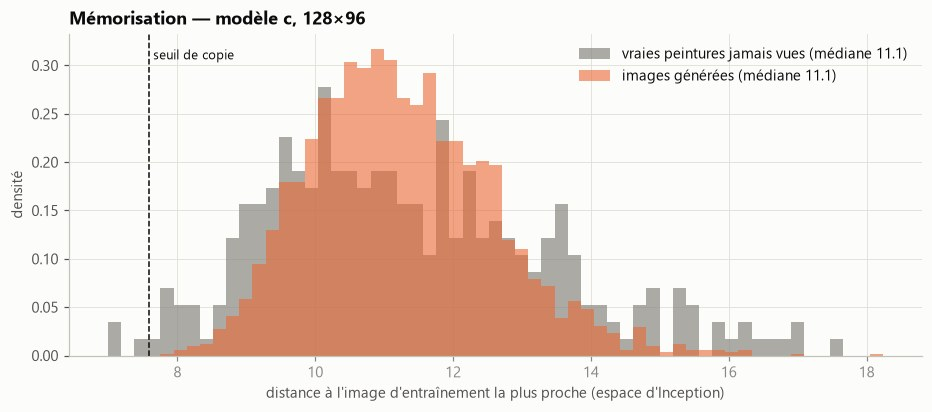

mem_ratio = 1.002 ; part d'images générées sous le seuil de copie : 0.00% (≈ 1 % attendu)


In [6]:
(ROOT / "models").mkdir(exist_ok=True)
shutil.copy2(RUNS / "landscape_64_best_s42" / "checkpoints" / "best.pt", ROOT / "models" / "landscape_64.pt")
shutil.copy2(RUNS / "landscape_128_w64_s42" / "checkpoints" / "best.pt", ROOT / "models" / "landscape_128.pt")
print("Copiés : models/landscape_64.pt, models/landscape_128.pt")

G = GEN["landscape_128_w64_s42"]
ref128 = mt.Reference.load_or_compute(GENRE, BIG, ds.DATASETS / GENRE)
train_all = ds.load_split(GENRE, "train", BIG)
z = tr.evaluation_latents(len(ref128.train), G.nz, next(G.parameters()).device, seed=42)
f_gen, _ = mt.extract_features(tr.generate(G, z, batch_size=128))
dist = lambda a, b: torch.cdist(torch.from_numpy(a).float().cuda(), torch.from_numpy(b).float().cuda())
d_gen = dist(f_gen, ref128.train).min(1).values.cpu().numpy()
d_test = dist(ref128.test, ref128.train).min(1).values.cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 3.8))
bins = np.linspace(min(d_gen.min(), d_test.min()), max(d_gen.max(), d_test.max()), 60)
ax.hist(d_test, bins=bins, density=True, color=MUTED, alpha=0.7, label=f"vraies peintures jamais vues (médiane {np.median(d_test):.1f})")
ax.hist(d_gen, bins=bins, density=True, color=CAT[1], alpha=0.6, label=f"images générées (médiane {np.median(d_gen):.1f})")
thr = np.percentile(d_test, 1)
ax.axvline(thr, color=INK, ls="--", lw=1); ax.text(thr, ax.get_ylim()[1] * 0.92, " seuil de copie", fontsize=8.5)
ax.set_xlabel("distance à l'image d'entraînement la plus proche (espace d'Inception)"); ax.set_ylabel("densité")
ax.set_title("Mémorisation — modèle c, 128×96"); ax.legend()
save(fig, "05_memorization")
plt.show()
print(f"mem_ratio = {np.median(d_gen) / np.median(d_test):.3f} ; part d'images générées sous le seuil de copie : {(d_gen < thr).mean():.2%} (≈ 1 % attendu)")

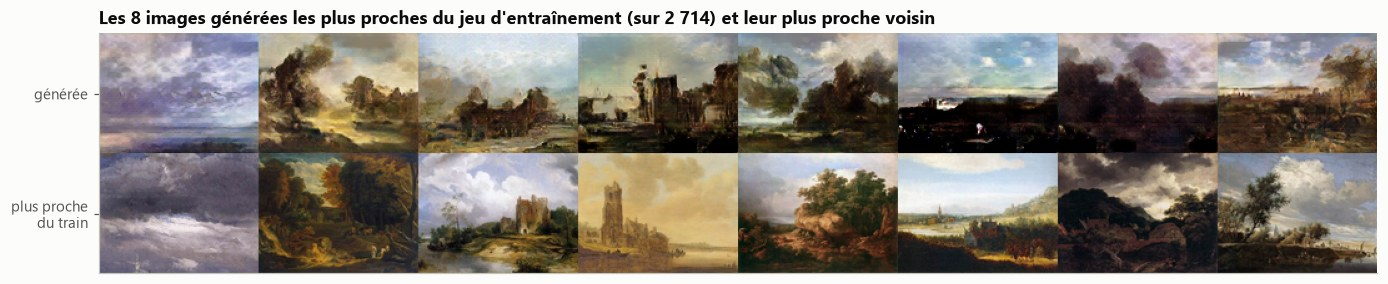

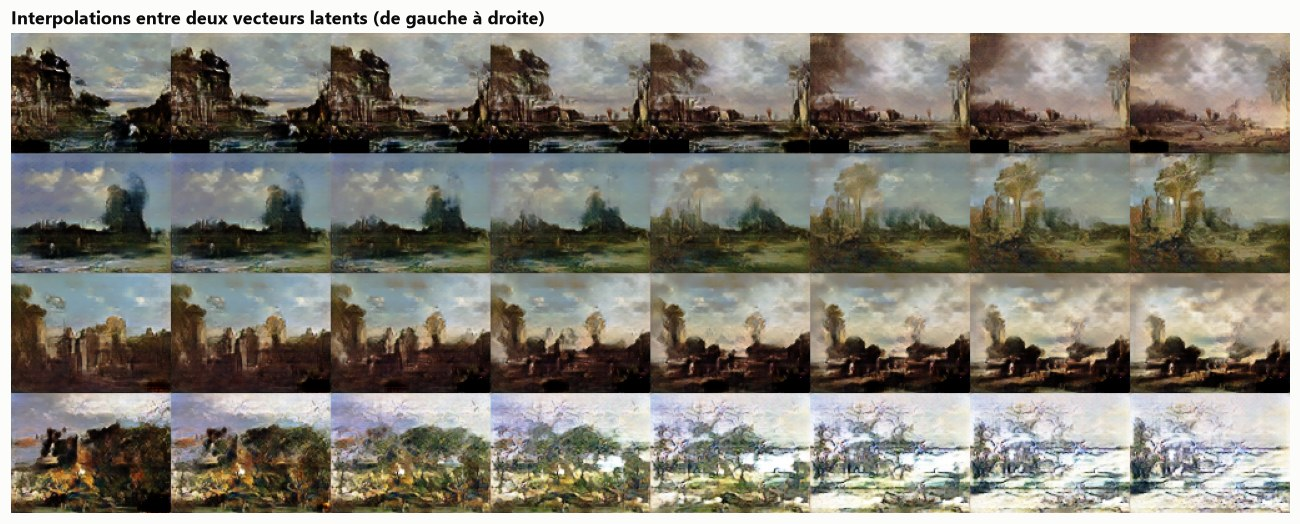

In [7]:
# Les 8 images générées les PLUS PROCHES du jeu d'entraînement : le cas le plus défavorable
worst = np.argsort(d_gen)[:8]
imgs = tr.generate(G, z[worst], batch_size=8).permute(0, 2, 3, 1).cpu().numpy()
nn_idx = dist(f_gen[worst], ref128.train).argmin(1).cpu().numpy()
fig, ax = plt.subplots(figsize=(15, 3.6))
ax.imshow(np.concatenate([np.concatenate(list(imgs), axis=1), np.concatenate([train_all[i] for i in nn_idx], axis=1)]))
ax.set_xticks([]); ax.set_yticks([BIG[1] / 2, BIG[1] * 1.5], ["générée", "plus proche\ndu train"]); ax.grid(False)
ax.set_title("Les 8 images générées les plus proches du jeu d'entraînement (sur 2 714) et leur plus proche voisin")
save(fig, "06_nearest_neighbors")
plt.show()

def slerp(a, b, t):
    omega = torch.acos((a / a.norm() * b / b.norm()).sum().clamp(-1, 1))
    return (torch.sin((1 - t) * omega) * a + torch.sin(t * omega) * b) / torch.sin(omega)


g = torch.Generator().manual_seed(7)
strips = []
with torch.no_grad():
    for _ in range(4):
        a, b = torch.randn(G.nz, generator=g), torch.randn(G.nz, generator=g)
        zz = torch.stack([slerp(a, b, t) for t in torch.linspace(0, 1, 8)]).to(next(G.parameters()).device)
        x = G(zz).clamp(-1, 1).add(1).mul(127.5).round().to(torch.uint8).permute(0, 2, 3, 1).cpu().numpy()
        strips.append(np.concatenate(list(x), axis=1))
fig, ax = plt.subplots(figsize=(15, 5.8))
ax.imshow(np.concatenate(strips)); ax.axis("off")
ax.set_title("Interpolations entre deux vecteurs latents (de gauche à droite)")
save(fig, "07_interpolation")
plt.show()

**Observations**

- **La distribution des distances des images générées se superpose à celle des vraies peintures jamais vues**
  (même médiane, 11,1), en plus resserrée. **Aucune image générée n'est sous le seuil de copie.**
- **Même les 8 images les plus proches du jeu d'entraînement ne sont pas des copies** : elles partagent une ambiance
  avec leur voisin (ciel nuageux, masse d'arbres sombre, ruine) mais pas la composition.
- **Interpolations continues** : un ciel s'éclaircit, un arbre apparaît, la saison change, sans saut.
- Le score légèrement sous 1 observé en 64×48 (0,96) ne correspond donc pas à de la copie : il traduit des images
  « typiques », proches du centre de la distribution.

## 6. Conclusion

| | a · DCGAN de base | b · réglage Optuna | c · réglage Optuna |
|---|---|---|---|
| Résolution | 64×48 | 64×48 | 128×96 |
| FID à la résolution d'origine | 79,8 | 42,3 | 61,9 |
| **FID évalué en 64×48** | 79,8 | 42,3 | **37,7** |
| Précision / rappel évalués en 64×48 | 0,83 / 0,03 | 0,86 / 0,20 | 0,82 / 0,28 |
| Couverture évaluée en 64×48 | 0,40 | 0,70 | 0,76 |
| Mémorisation | aucune | aucune | aucune |
| Temps de calcul (hors évaluations) | 7 min | 16 min | 73 min |

**Réponses aux questions posées.**

1. **Les hyperparamètres trouvés sur les portraits se transposent aux paysages**, sans aucun réglage : FID presque
   divisé par deux, discriminateur à l'équilibre, entraînement stable. Ce que l'étude Optuna a trouvé n'est donc pas
   une particularité des portraits, mais une façon d'équilibrer le jeu entre les deux réseaux.
2. **La montée en résolution fonctionne aussi**, avec un gain plus modeste que pour les portraits.
3. **Les mêmes faiblesses se retrouvent** : démarrage lent en haute résolution, diversité des détails fins limitée.

**Modèles retenus** : `models/landscape_64.pt` (modèle b) et `models/landscape_128.pt` (modèle c).

**Limites.**

- Un seul entraînement par modèle.
- Les modèles b et c progressaient encore à la dernière époque.
- Aucune recherche d'hyperparamètres propre aux paysages : on a vérifié que les réglages des portraits fonctionnent,
  pas qu'ils sont les meilleurs possibles ici.
- Le démarrage lent en 128×96 a coûté une centaine d'époques.

**Suites possibles.**

- Prolonger le modèle c, qui n'avait pas convergé.
- L'application Streamlit dispose maintenant de quatre modèles : portraits et paysages, en deux résolutions.